In [11]:
import torch
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from xFNO import *
from special_loss_functions import *

random.seed(100)
device = "cpu"

In [12]:
def train(dataloader, model, loss_fn, optimizer, device):
    num_batches = len(dataloader)
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)     
        pred = model(X)
        loss = loss_fn(pred, y)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss /= num_batches
    return loss

def test(dataloader, model, loss_fn, device):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
    loss /= num_batches
    return loss

In [13]:
# inputs [B, Nx, Nf]
# outputs [B, Nx, Nt, Nf]
def make_training_testing_datasets(data, history, batch_size):

    # select
    features = torch.tensor(data[:-history, :])
    labels = [torch.tensor(data[i+1:i+1+history, :]).t() for i in range(len(data)-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)
    labels = torch.stack(labels)
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)
    print(labels.shape)

    # create datasets
    training_size = 1024
    idx = torch.randperm(training_size)
    training_dataset = TensorDataset(features[idx, :, :], labels[idx, :, :, :])
    testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :, :, :])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

In [14]:
# Load PDE solution
with open('data/KuramotoSivashinsky/KS_N32.pkl', 'rb') as file:
    data = pickle.load(file)

In [15]:
# create data structures
history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets(data, history, batch_size)

torch.Size([1996, 32, 5, 1])


In [16]:
# initialize operator
Nf = dimensions[-1]
Nx = dimensions[1]
Nlifted = 16 # 32 works
Nk_truncated = 10
depth = history

neuralop = FNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth
            ).to(device) 


total_params = sum(p.numel() for p in neuralop.parameters())
print(total_params)


loss_fn_test = torch.nn.MSELoss(reduction='mean')
loss_fn = H1Loss(reduction='mean', dim=(1,)) # dim=1 only computes spatial norm. None: the error includes the temporal dimension

rate = 2e-04
optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)

23409


Train Loss: 0.14114, Test Loss: 1.65944
Train Loss: 0.00234, Test Loss: 0.02968
Train Loss: 0.00035, Test Loss: 0.00315
Train Loss: 0.00015, Test Loss: 0.00136
Train Loss: 0.00008, Test Loss: 0.00092
final learning rate: 6.553600000000003e-05


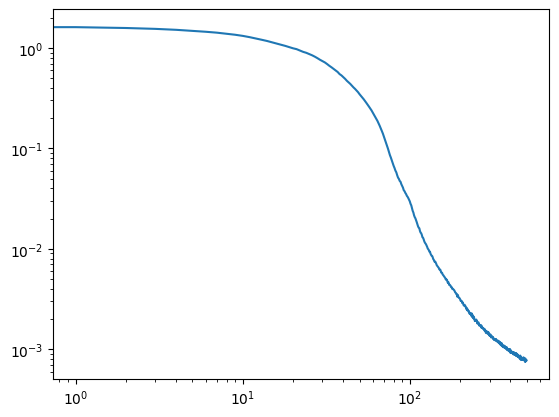

In [17]:
# train
rate = 2e-04
testing_loss = []
training_loss = []
epochs = 500
for i in range(epochs):
    training_loss += [train(training_dataloader, neuralop, loss_fn, optimizer_neuralop, device)]
    testing_loss += [test(testing_dataloader, neuralop, loss_fn_test, device)]
    if i%100==0:
        print(f"Train Loss: {(training_loss[-1]):>0.5f}, Test Loss: {(testing_loss[-1]):>0.5f}")        
        rate *= 0.8
        optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)

print(f'final learning rate: {rate}')
plt.figure()
plt.plot(testing_loss)
plt.loglog()
PATH = "models/KuramotoSivashinsky/FNO.pth"
torch.save(neuralop.state_dict(), PATH)
param_list = [(Nx, Nf), Nlifted, (Nk_truncated,), depth]
PARAM_PATH="models/KuramotoSivashinsky/FNO_parameters"
with open(PARAM_PATH, 'wb') as f:
    pickle.dump(param_list, f)

In [18]:
Nf = 1
Nlifted = 16 # 32 works
Nk_truncated = 10
depth = history

neuralop_p = PFNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth
            ).to(device) 

total_params_p = sum(p.numel() for p in neuralop_p.parameters())
print(total_params_p)

rate = 2e-04
loss_fn_test = torch.nn.MSELoss(reduction='mean')
loss_fn = H1Loss(reduction='mean', dim=(1,)) # dim=1 only computes spatial norm. None: the error includes the temporal dimension
optimizer_neuralop_p = torch.optim.Adam(neuralop_p.parameters(), lr=rate)

23409


Train Loss: 0.12724, Test Loss: 1.44367
Train Loss: 0.00114, Test Loss: 0.00862
Train Loss: 0.00042, Test Loss: 0.00220
Train Loss: 0.00053, Test Loss: 0.00150
Train Loss: 0.00021, Test Loss: 0.00119
final learning rate: 6.553600000000003e-05


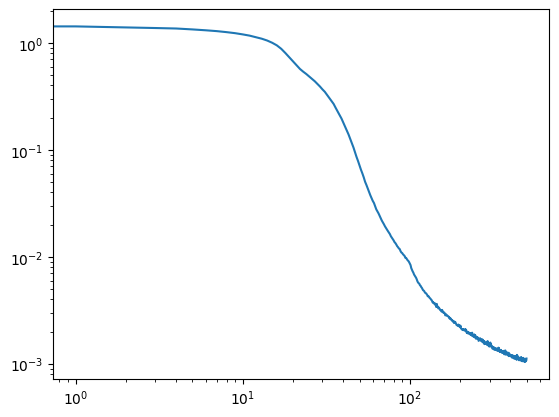

In [19]:
# train
testing_loss = []
training_loss = []
epochs = 500
rate = 2e-04
for i in range(epochs):
    training_loss += [train(training_dataloader, neuralop_p, loss_fn, optimizer_neuralop_p, device)]
    testing_loss += [test(testing_dataloader, neuralop_p, loss_fn_test, device)]
    if i%100==0:
        print(f"Train Loss: {(training_loss[-1]):>0.5f}, Test Loss: {(testing_loss[-1]):>0.5f}")        
        rate *= 0.8
        optimizer_neuralop_p = torch.optim.Adam(neuralop_p.parameters(), lr=rate)
        
print(f'final learning rate: {rate}')
plt.figure()
plt.plot(testing_loss)
plt.loglog()
PATH2 = "models/KuramotoSivashinsky/PFNO.pth"
torch.save(neuralop_p.state_dict(), PATH2)
PARAM_PATH2="models/KuramotoSivashinsky/PFNO_parameters"
param_list = [(Nx, Nf), Nlifted, (Nk_truncated,), depth]
with open(PARAM_PATH2, 'wb') as f:
    pickle.dump(param_list, f)

mass of estimate 1: -0.0007147043943405151, mass of estimate 2: -2.9802322387695312e-08, mass of solution: 5.592748486549226e-15


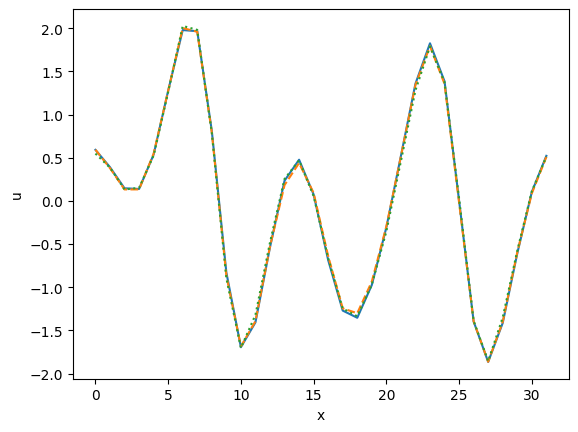

KeyboardInterrupt: 

In [22]:
# unroll, a priori model
# test farthest prediction in the future
with open(PARAM_PATH, 'rb') as f: loaded_parameters = pickle.load(f)
neuralop = FNO(*loaded_parameters).to(device)
neuralop.load_state_dict(torch.load("models/KuramotoSivashinsky/FNO.pth"))

with open(PARAM_PATH2, 'rb') as f: loaded_parameters = pickle.load(f)
neuralop_p = PFNO(*loaded_parameters).to(device)
neuralop_p.load_state_dict(torch.load("models/KuramotoSivashinsky/PFNO.pth"))
training_size = 1024

neuralop.eval()
neuralop_p.eval()
fig, ax = plt.subplots()
data = torch.tensor(data)

for i in range(data[training_size:-history, :].size()[0]):
    uin = torch.reshape(data[training_size+i, :].to(torch.float32), (1, Nx, 1))
    
    u_pred = neuralop(uin) # don't extrapolate, recompute prediction    
    u1_plot = u_pred.detach().numpy().squeeze()[:, -1]
    mass1 = np.mean(u1_plot)

    u_pred = neuralop_p(uin)
    u2_plot = u_pred.detach().numpy().squeeze()[:, -1]
    mass2 = np.mean(u2_plot)
    
    clear_output(wait=True)
    print(f'mass of estimate 1: {mass1}, mass of estimate 2: {mass2}, mass of solution: {torch.mean(data[i+training_size, :])}')
    fig, ax = plt.subplots()
    ax.plot(data[i+training_size+history+1, :])
    ax.plot(u1_plot, '--')
    ax.plot(u2_plot, ':')
    plt.xlabel('x')
    plt.ylabel('u')
    plt.show()
    plt.pause(0.05)

/var/folders/xb/jv56kxg50qq6d3l4hn2ws12w0000gn/T/ipykernel_33660/1796207005.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data)


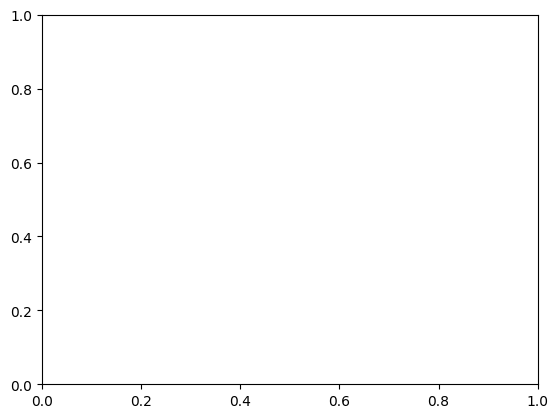

In [59]:
# save gif
PARAM_PATH="models/KuramotoSivashinsky/FNO_parameters"
PARAM_PATH2="models/KuramotoSivashinsky/PFNO_parameters"
with open(PARAM_PATH, 'rb') as f: loaded_parameters = pickle.load(f)
neuralop = FNO(*loaded_parameters).to(device)
neuralop.load_state_dict(torch.load("models/KuramotoSivashinsky/FNO.pth"))

with open(PARAM_PATH2, 'rb') as f: loaded_parameters = pickle.load(f)
neuralop_p = PFNO(*loaded_parameters).to(device)
neuralop_p.load_state_dict(torch.load("models/KuramotoSivashinsky/PFNO.pth"))
training_size = 1024

neuralop.eval()
neuralop_p.eval()
fig, ax = plt.subplots()
data = torch.tensor(data)
t = 0
for i in range(data[training_size:-history, :].size()[0]-history):
    t += 1
    uin = torch.reshape(data[training_size+i, :].to(torch.float32), (1, Nx, 1))
    
    u_pred = neuralop(uin) # don't extrapolate, recompute prediction    
    u1_plot = u_pred.detach().numpy().squeeze()[:, -1]
    mass1 = np.mean(u1_plot)

    u_pred = neuralop_p(uin)
    u2_plot = u_pred.detach().numpy().squeeze()[:, -1]
    mass2 = np.mean(u2_plot)
    
    #clear_output(wait=True)
    #print(f'mass of estimate 1: {mass1}, mass of estimate 2: {mass2}, mass of solution: {torch.mean(data[i+training_size, :])}')
    fig, ax = plt.subplots()
    ax.plot(data[i+training_size+history+1, :], 'k-')
    ax.plot(u1_plot, 'b--', label='FNO')
    ax.plot(u2_plot, 'm:', label='PFNO')
    plt.xlabel('x')
    plt.ylabel('u')
    #plt.show()
    #plt.pause(0.05)
    plt.legend()
    plt.savefig(f'frames/frame_{t:03d}.png', transparent=False)
    plt.close(fig)
import imageio.v2 as imageio
import os
frames = []
for ti in range(t):
    image = imageio.imread(f'frames/frame_{ti+1:03d}.png')
    frames.append(image)

# Save the list of frames as a GIF
imageio.mimsave(f'KS1D_N32.gif', frames, fps=10) # `fps` controls the speed

# Clean up the individual frame files (optional)
for ti in range(t):
    os.remove(f'frames/frame_{ti+1:03d}.png')

In [25]:
# Apply model on higher prediction data
# first, load the data
with open('data/KuramotoSivashinsky/KS_N128.pkl', 'rb') as file:
    data_hr = pickle.load(file)

# create data structures
history = 5
batch_size = 64
training_dataloader_hr, testing_dataloader_hr, dimensions_hr = make_training_testing_datasets(data_hr, history, batch_size)
Nx_hr = dimensions_hr[1]

torch.Size([1996, 128, 5, 1])


In [26]:
# X: batch of tensors
# Nx: target resolution (smaller)
def fft_downsample(X, Nx):
    X = torch.fft.rfft(X, dim=1, norm="backward")
    return torch.fft.irfft(X[:, :Nx//2+1, :], dim=1, norm="backward")

def fft_upsample(X, Nx, Nx_hr):
    Xsize = X.shape
    
    X = torch.fft.rfft(X, dim=1, norm="backward")
    X = torch.cat((X[:, :Nx//2+1, :, :], torch.zeros((Xsize[0], Nx_hr//2-Nx//2) + Xsize[2:])), 1)
    X = torch.fft.irfft(X, dim=1, norm="backward")
    return X

# downsample, predict, upsample
def test_hr(dataloader, model, loss_fn, Nx):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            Nx_hr = X.size()[1]
            batch_size = X.size()[0]

            # downsample
            X = fft_downsample(X, Nx)

            
            # predict
            pred = model(X).detach()

            # upsample
            pred = fft_upsample(pred, Nx, Nx_hr)

            # loss
            loss += loss_fn(pred, y).item()
            
    loss /= num_batches
    return loss

In [27]:
progress = test_hr(testing_dataloader_hr, neuralop, loss_fn, Nx)
progress_p = test_hr(testing_dataloader_hr, neuralop_p, loss_fn, Nx)
print(progress)
print(progress_p)

0.10823278641328216
0.0015585327419103123


In [29]:
# plot results
neuralop.eval()
neuralop_p.eval()
data_hr = torch.tensor(data_hr)
for i in range(data_hr.shape[0]):
    uin = torch.reshape(data_hr[i, :].to(torch.float32), (1, Nx_hr, 1))
    # downsample
    uin = torch.fft.rfft(uin, dim=1, norm="backward")
    uin = uin[:, :Nx//2+1, :]
    uin = torch.fft.irfft(uin, dim=1, norm="backward")

    # predict
    u_pred = neuralop(uin).detach()
    u_pred2 = neuralop_p(uin).detach()

    # upsample
    pred_size = u_pred.shape
    u_pred = torch.fft.rfft(u_pred, dim=1, norm="backward")
    u_pred = torch.cat((u_pred[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred = torch.fft.irfft(u_pred, dim=1, norm="backward")

    u_pred2 = torch.fft.rfft(u_pred2, dim=1, norm="backward")
    u_pred2 = torch.cat((u_pred2[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred2 = torch.fft.irfft(u_pred2, dim=1, norm="backward")
    
    clear_output(wait=True)
    fig, ax = plt.subplots()
    
    ax.plot(data_hr[i+history, :])
    ax.plot(u_pred.detach().numpy().squeeze()[:, -1], '--', label = 'FNO')
    ax.plot(u_pred2.detach().numpy().squeeze()[:, -1], ':', label='PFNO')
    plt.xlabel('x')
    plt.ylabel('u')
    plt.legend()
    plt.show()
    plt.pause(0.1)

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [55]:
# gif
neuralop.eval()
neuralop_p.eval()
data_hr = torch.tensor(data_hr)
t = 0
for i in range(data_hr.shape[0]-history-1):
    t += 1
    uin = torch.reshape(data_hr[i, :].to(torch.float32), (1, Nx_hr, 1))
    # downsample
    uin = torch.fft.rfft(uin, dim=1, norm="backward")
    uin = uin[:, :Nx//2+1, :]
    uin = torch.fft.irfft(uin, dim=1, norm="backward")

    # predict
    u_pred = neuralop(uin).detach()
    u_pred2 = neuralop_p(uin).detach()

    # upsample
    pred_size = u_pred.shape
    u_pred = torch.fft.rfft(u_pred, dim=1, norm="backward")
    u_pred = torch.cat((u_pred[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred = torch.fft.irfft(u_pred, dim=1, norm="backward")

    u_pred2 = torch.fft.rfft(u_pred2, dim=1, norm="backward")
    u_pred2 = torch.cat((u_pred2[:, :Nx//2+1, :], torch.zeros((1, Nx_hr//2-Nx//2) + pred_size[2:])), 1)
    u_pred2 = torch.fft.irfft(u_pred2, dim=1, norm="backward")
    
    #clear_output(wait=True)
    plt.figure()
    
    plt.plot(data_hr[i+history, :], 'k-')
    plt.plot(u_pred.detach().numpy().squeeze()[:, -1], 'b--', label = 'FNO')
    plt.plot(u_pred2.detach().numpy().squeeze()[:, -1], 'm:', label='PFNO')
    plt.xlabel('x')
    plt.ylabel('u')
    plt.legend()
    #plt.show()
    #plt.pause(0.1)
    plt.savefig(f'frames/frame_{t:03d}.png', transparent=False)
    plt.clf()
    plt.close()

import imageio.v2 as imageio
import os
frames = []
for ti in range(t):
    image = imageio.imread(f'frames/frame_{ti+1:03d}.png')
    #print(image.shape)
    frames.append(image)

# Save the list of frames as a GIF
imageio.mimsave(f'KS1D_N64_using_N32_emulator.gif', frames, fps=10) # `fps` controls the speed

# Clean up the individual frame files (optional)
for ti in range(t):
    os.remove(f'frames/frame_{ti+1:03d}.png')


/var/folders/xb/jv56kxg50qq6d3l4hn2ws12w0000gn/T/ipykernel_33660/3147937405.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_hr = torch.tensor(data_hr)


# Remarks
## FNO that conserves mass does a better job with the higher resolution data
## must apply conservation law before the nonlinear activation to avoid contamination

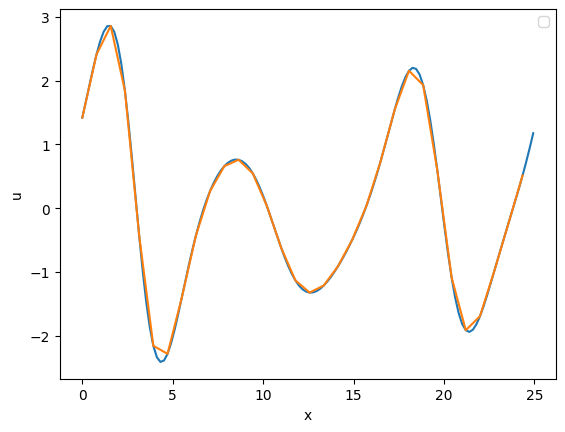

KeyboardInterrupt: 

In [24]:
# make sure high res and low res solutions are  matched
L = 8*np.pi
x_hr = np.linspace(0, L, 128, endpoint=False)
x = np.linspace(0, L, 32, endpoint=False)
for i in range(data_hr.shape[0]):
    clear_output(wait=True)
    fig, ax = plt.subplots()
    ax.plot(x_hr, data_hr[i, :])
    ax.plot(x, data[i, :])
    plt.xlabel('x')
    plt.ylabel('u')
    plt.legend()
    plt.show()
    plt.pause(0.1)

In [40]:
# Let's train a high res model
# data
with open('data/KuramotoSivashinsky/KS_N128.pkl', 'rb') as file:
    data_hr = pickle.load(file)
with open('data/KuramotoSivashinsky/KS_N32.pkl', 'rb') as file:
    data = pickle.load(file)

# define dataloaders
def make_training_testing_datasets_residual(data, data2, history, batch_size):

    # select
    features = torch.tensor(data[:-history, :])
    labels = [torch.tensor(data[i:i+history, :]).t() for i in range(len(data)-history)]
    labels2 = [torch.tensor(data2[i:i+history, :]).t() for i in range(len(data)-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)

    # labels
    labels = torch.stack(labels)
    labels2 = torch.stack(labels2)

    # downsample
    labels2 = labels2[:, ::labels2.shape[1]//labels.shape[1], :]
    labels -= labels2
    if torch.mean(labels2).item() < 1e-08: raise ValueError("the residuals are tiny, no model needed")
    
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)

    # create datasets
    training_size = 1024
    idx = torch.randperm(training_size)
    training_dataset = TensorDataset(features[idx, :, :], labels[idx, :, :, :])
    testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :, :, :])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

# create data structures
device = "cpu"
history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets_residual(data, data_hr, history, batch_size)
Nx = dimensions[1]

# operator
Nf = 1
Nlifted = 16 
Nk_truncated = 10
depth = history

neuralop_p = PFNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth
            ).to(device) 

total_params_p = sum(p.numel() for p in neuralop_p.parameters())

rate = 2e-04
loss_fn_test = torch.nn.MSELoss(reduction='mean')
loss_fn = H1Loss(reduction='mean', dim=1) # dim=1 only computes spatial norm. None: the error includes the temporal dimension
optimizer_neuralop_p = torch.optim.Adam(neuralop_p.parameters(), lr=rate)

# training
epochs = 500
rate = 2e-04
for i in range(epochs):   
    training_loss = train(training_dataloader, neuralop_p, loss_fn, optimizer_neuralop_p, device)
    if i%100==0:
        testing_loss = test(testing_dataloader, neuralop_p, loss_fn_test, device)
        print(f"Train Loss: {(training_loss):>0.5f}, Test Loss: {(testing_loss):>0.5f}")        
        rate *= 0.8
        optimizer_neuralop_p = torch.optim.Adam(neuralop_p.parameters(), lr=rate)
        
print(f'final learning rate: {rate}')
PATH = "models/KuramotoSivashinsky/PFNO_N128.pth"
torch.save(neuralop_p.state_dict(), PATH)
PARAM_PATH="models/KuramotoSivashinsky/PFNO_parameters"
param_list = [(Nx, Nf), Nlifted, (Nk_truncated,), depth]
with open(PARAM_PATH, 'wb') as f:
    pickle.dump(param_list, f)

ValueError: the residuals are tiny, no model needed